# EzzSteel Sales Data Analysis
**Basic Sales Data Analysis Portfolio Project**

This notebook analyzes real invoice-level sales data for **EzzSteel**, a steel manufacturer, to understand
overall sales performance and extract data-driven business insights.

**Dataset used:** `Sales_Transactions` sheet of `EzzSteel_Full_Dataset.xlsx` (2,408 invoices, 2020-2023).

The source workbook contains several sheets (production, financials, raw materials, maintenance). This
project focuses on the **Sales_Transactions** sheet because it is the one that matches a classic sales-analysis
structure (date, product, quantity, revenue, customer, region). Column names differ from a generic template,
so they are mapped like this:

| Generic concept | Actual column in this dataset |
|---|---|
| Order Date | `Invoice_Date` |
| Category  | `Product_Type` (Long Steel / Flat Steel) |
| Product   | `Steel_Grade` (specific grade sold, e.g. B500C, ST52) |
| Region    | `Country` (Egypt for domestic sales, export country otherwise) |
| Quantity  | `Quantity_Tons` |
| Sales     | `Revenue_EGP` |
| Profit    | **Not available at the transaction level** — see the note in Section 6 |


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 25)


## 2. Load and Inspect the Dataset

The workbook has multiple sheets. We load the `Sales_Transactions` sheet, which holds one row per
invoice line — the closest match to a typical "store sales" dataset.

In [2]:
RAW_PATH = 'EzzSteel_Full_Dataset.xlsx'

df = pd.read_excel(RAW_PATH, sheet_name='Sales_Transactions')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(10)


Shape: 2408 rows x 20 columns


,Invoice_ID,Invoice_Date,Customer_ID,Customer_Name,Customer_Segment,Governorate,Country,Product_Type,Steel_Grade,Thickness_mm,Width_mm,Quantity_Tons,Unit_Price_EGP,Revenue_EGP,Payment_Terms_Days,Actual_Payment_Days,Discount_%,Is_Export,Currency,Exchange_Rate_EGP
0,INV-11720,2022-09-08,CUST-0155,t 155,Government,Gharbia,Egypt,Flat Steel (HRC),ST52,12.0,1200,305.4,17340,5295636,30,42,2.0,No,EGP,1.00
1,INV-11244,2022-06-18,CUST-0247,r 247,Manufacturer,—,Saudi Arabia,Long Steel,SD490,25.0,0,1518.2,17809,27037624,120,117,1.6,Yes,USD,21.50
2,INV-10621,2021-11-06,CUST-0125,s 125,Trading_Co,Cairo,Egypt,Flat Steel (HRC),HSLA340,2.5,1000,1335.3,14175,18927878,60,76,3.2,No,EGP,1.00
3,INV-10686,2021-05-04,CUST-0161,l 161,Government,Suez,Egypt,Long Steel,B500B,28.0,0,1069.2,13905,14867226,30,51,1.4,No,EGP,1.00
4,INV-11671,2022-05-01,CUST-0140,a 140,Contractor,Sharqia,Egypt,Long Steel,B500C,12.0,0,1182.3,17000,20099100 EGP,30,45,3.4,No,EGP,1.00
5,INV-10689,2021-05-20,CUST-0291,291,Government,—,Tunisia,Flat Steel (HRC),API5L,1.5,1200,873.3,14726,12860216,60,81,2.4,Yes,USD,15.70
6,INV-11596,2022-09-02,CUST-0026,u 26,Developer,Cairo,Egypt,Flat Steel (HRC),HSLA420,5.0,1200,1202.7,18020,21672654,90,89,1.5,No,EGP,1.00
7,INV-11803,2023-05-06,CUST-0148,o 148,Manufacturer,Alexandria,Egypt,Long Steel,B500C,16.0,0,2133.3,25750,54932475,120,135,0.5,No,EGP,1.00
8,INV-10436,2020-12-14,CUST-0122,T 122,Manufacturer,—,Libya,Long Steel,B400B,18.0,0,151.8,8813,1337813,120,131,1.1,Yes,USD,15.75
9,INV-11616,2022-11-16,CUST-0062,S 62,Trading_Co,Alexandria,Egypt,Long Steel,B400B,10.0,0,1864.1,16490,30739009,60,55,1.3,No,EGP,1.00


In [3]:
print("Column names:")
print(df.columns.tolist())


Column names:
['Invoice_ID', 'Invoice_Date', 'Customer_ID', 'Customer_Name', 'Customer_Segment', 'Governorate', 'Country', 'Product_Type', 'Steel_Grade', 'Thickness_mm', 'Width_mm', 'Quantity_Tons', 'Unit_Price_EGP', 'Revenue_EGP', 'Payment_Terms_Days', 'Actual_Payment_Days', 'Discount_%', 'Is_Export', 'Currency', 'Exchange_Rate_EGP']


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2408 entries, 0 to 2407
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Invoice_ID           2408 non-null   str    
 1   Invoice_Date         2408 non-null   str    
 2   Customer_ID          2408 non-null   str    
 3   Customer_Name        2408 non-null   str    
 4   Customer_Segment     2408 non-null   str    
 5   Governorate          2408 non-null   str    
 6   Country              2408 non-null   str    
 7   Product_Type         2408 non-null   str    
 8   Steel_Grade          2408 non-null   str    
 9   Thickness_mm         2408 non-null   float64
 10  Width_mm             2408 non-null   int64  
 11  Quantity_Tons        2386 non-null   float64
 12  Unit_Price_EGP       2408 non-null   int64  
 13  Revenue_EGP          2408 non-null   object 
 14  Payment_Terms_Days   2408 non-null   int64  
 15  Actual_Payment_Days  2408 non-null   int64  
 16 

In [5]:
# Descriptive statistics for numeric columns
df.describe(include='number').T


,count,mean,std,min,25%,50%,75%,max
Thickness_mm,2408.0,13.151993,8.669373,1.5,6.000,12.0,18.000,32.0
Width_mm,2408.0,481.063123,627.850865,0.0,0.000,0.0,1200.000,1600.0
Quantity_Tons,2386.0,7712.013076,98311.514065,-2476.7,679.825,1261.3,1863.175,2354000.0
Unit_Price_EGP,2408.0,16391.219684,6199.084271,7990.0,12690.000,15980.0,23500.000,28620.0
Payment_Terms_Days,2408.0,75.971761,33.578475,30.0,60.000,90.0,120.000,120.0
Actual_Payment_Days,2408.0,85.950581,34.850939,25.0,55.000,86.0,115.000,145.0
Discount_%,2408.0,2.431271,10.048703,0.0,0.900,1.7,2.600,150.0
Exchange_Rate_EGP,2408.0,6.739286,9.631457,1.0,1.000,1.0,15.700,30.9


In [6]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nExact duplicate rows:", df.duplicated().sum())


Missing values per column:
Quantity_Tons    22
dtype: int64

Exact duplicate rows: 8


**What this tells us:**
- The dataset has 2,408 invoice lines and 20 columns covering the customer, product, quantity, price,
  revenue, and payment terms of each sale.
- `Quantity_Tons` has 22 missing values.
- There are 8 fully duplicated rows.
- `Revenue_EGP` is loaded as **text**, not a number — some values contain the literal suffix `" EGP"`,
  which stops pandas from reading the whole column as numeric.
- `Invoice_Date` is also text, and (checked below) is not in one consistent format.


## 3. Data Cleaning

Each cleaning step below is applied only after confirming the problem exists in the data, and the
reasoning for each fix is explained.

### 3.1 Duplicate rows

In [7]:
dupe_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {dupe_count} exact duplicate rows -> {len(df)} rows remain.")


Removed 8 exact duplicate rows -> 2400 rows remain.


### 3.2 Fixing `Revenue_EGP` (should be numeric)
Some values are stored as text like `'20099100 EGP'` instead of a plain number. We strip the currency
text and thousands separators, then convert to a proper numeric column.

In [8]:
df['Revenue_EGP'] = (
    df['Revenue_EGP'].astype(str)
      .str.replace(' EGP', '', regex=False)
      .str.replace(',', '', regex=False)
)
df['Revenue_EGP'] = pd.to_numeric(df['Revenue_EGP'], errors='coerce')
print("Non-numeric Revenue_EGP values remaining after cleaning:", df['Revenue_EGP'].isna().sum())


Non-numeric Revenue_EGP values remaining after cleaning: 0


### 3.3 Fixing `Invoice_Date` (mixed date formats)
Most dates are already `YYYY-MM-DD`, but a handful are written as `DD/MM/YYYY` (e.g. `24/9/2021`).
We detect the two formats separately and parse each with the correct rule, instead of letting pandas
guess (which would silently produce wrong dates for some rows).

In [9]:
iso_mask = df['Invoice_Date'].astype(str).str.match(r'^\d{4}-\d{2}-\d{2}$')
print(f"Rows already in ISO (YYYY-MM-DD) format: {iso_mask.sum()}")
print(f"Rows in DD/MM/YYYY format needing special parsing: {(~iso_mask).sum()}")

parsed_dates = pd.Series(index=df.index, dtype='datetime64[ns]')
parsed_dates.loc[iso_mask] = pd.to_datetime(df.loc[iso_mask, 'Invoice_Date'], format='%Y-%m-%d')
parsed_dates.loc[~iso_mask] = pd.to_datetime(df.loc[~iso_mask, 'Invoice_Date'], dayfirst=True)
df['Invoice_Date'] = parsed_dates

print("Unparseable dates:", df['Invoice_Date'].isna().sum())
print("Date range:", df['Invoice_Date'].min().date(), "to", df['Invoice_Date'].max().date())


Rows already in ISO (YYYY-MM-DD) format: 2391
Rows in DD/MM/YYYY format needing special parsing: 9
Unparseable dates: 0
Date range: 2020-01-01 to 2023-12-28


### 3.4 Fixing `Quantity_Tons` (unit mix-ups, negative values, missing values)

Sorting the quantities reveals a clear break: normal invoices top out around **2,500 tons**, then jump
straight to **132,100+ tons** with no values in between. Those extreme values are a kilogram/ton mix-up
(the number was entered in kg instead of tons), so we correct them by dividing by 1,000 — after the fix
they land back in the normal 130–2,400 ton range, confirming the correction is right.

A few rows also have a **negative** quantity, which is not physically possible for a shipped quantity —
this is treated as a sign-entry error and corrected with the absolute value.

The 22 rows that are still missing a quantity after these fixes (< 1% of the data) are dropped, since a
sales-quantity figure can't be reasonably estimated for an individual invoice.

In [10]:
mixup_mask = df['Quantity_Tons'] > 10000
print(f"Kg/ton mix-up rows corrected (divided by 1000): {mixup_mask.sum()}")
df.loc[mixup_mask, 'Quantity_Tons'] = df.loc[mixup_mask, 'Quantity_Tons'] / 1000

neg_mask = df['Quantity_Tons'] < 0
print(f"Negative quantity rows corrected (sign flipped): {neg_mask.sum()}")
df.loc[neg_mask, 'Quantity_Tons'] = df.loc[neg_mask, 'Quantity_Tons'].abs()

missing_qty = df['Quantity_Tons'].isna().sum()
print(f"Rows still missing Quantity_Tons, dropped: {missing_qty}")
df = df.dropna(subset=['Quantity_Tons']).reset_index(drop=True)


Kg/ton mix-up rows corrected (divided by 1000): 12
Negative quantity rows corrected (sign flipped): 11
Rows still missing Quantity_Tons, dropped: 22


### 3.5 Fixing `Discount_%` (impossible values)
A discount above 100% is not valid. These 11 rows are capped at 100%, treating the excess as a data-entry error
rather than deleting the whole invoice (the revenue and quantity figures for these rows are still valid).

In [11]:
bad_discount = (df['Discount_%'] > 100).sum()
df.loc[df['Discount_%'] > 100, 'Discount_%'] = 100
print(f"Discount values above 100% capped: {bad_discount}")


Discount values above 100% capped: 11


### 3.6 Standardizing text categories
`Customer_Segment` and `Product_Type` contain the same category written with inconsistent casing/wording
(e.g. `'contractor'` vs `'Contractor'`, `'long steel rebar'` vs `'Long Steel'`). These are merged into a
single consistent label per category so they aren't counted as separate groups.

In [12]:
df['Customer_Segment'] = df['Customer_Segment'].str.strip().str.title()

df['Product_Type'] = df['Product_Type'].str.strip()
df['Product_Type'] = df['Product_Type'].replace({'long steel rebar': 'Long Steel'})

print("Customer_Segment categories:", sorted(df['Customer_Segment'].unique()))
print("Product_Type categories:", sorted(df['Product_Type'].unique()))


Customer_Segment categories: ['Contractor', 'Developer', 'Government', 'Manufacturer', 'Trading_Co']
Product_Type categories: ['Flat Steel (HRC)', 'Long Steel']


### 3.7 Final cleaned-dataset summary

In [13]:
print(f"Final shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Remaining missing values: {df.isnull().sum().sum()}")
print(f"Remaining duplicate rows: {df.duplicated().sum()}")
df.describe(include='number').T[['count','mean','min','max']]


Final shape: 2378 rows x 20 columns
Remaining missing values: 0
Remaining duplicate rows: 0


,count,mean,min,max
Thickness_mm,2378.0,1.317830e+01,1.5,32.0
Width_mm,2378.0,4.785324e+02,0.0,1600.0
Quantity_Tons,2378.0,1.268560e+03,50.5,2499.6
Unit_Price_EGP,2378.0,1.639942e+04,7990.0,28620.0
Revenue_EGP,2378.0,2.081457e+07,498576.0,69990480.0
Payment_Terms_Days,2378.0,7.589571e+01,30.0,120.0
Actual_Payment_Days,2378.0,8.587384e+01,25.0,145.0
Discount_%,2378.0,2.211564e+00,0.0,100.0
Exchange_Rate_EGP,2378.0,6.741211e+00,1.0,30.9


## 4. Create Additional Features

We derive `Year`, `Month`, and `Month_Name` from `Invoice_Date`, with months ordered chronologically
(January → December) rather than alphabetically. We also add simplified, template-style aliases for the
columns we'll analyze: `Category` (= Product_Type), `Product` (= Steel_Grade), `Region` (= Country),
`Sales` (= Revenue_EGP), `Quantity` (= Quantity_Tons).

In [14]:
df['Year'] = df['Invoice_Date'].dt.year
df['Month'] = df['Invoice_Date'].dt.month

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df['Month_Name'] = pd.Categorical(df['Invoice_Date'].dt.month_name(), categories=month_order, ordered=True)

# Simple aliases matching the generic project template
df['Category'] = df['Product_Type']          # Long Steel vs Flat Steel (HRC)
df['Product']  = df['Steel_Grade']            # specific steel grade sold
df['Region']   = df['Country']                # Egypt (domestic) or export destination
df['Sales']    = df['Revenue_EGP']
df['Quantity'] = df['Quantity_Tons']

df[['Invoice_Date','Year','Month','Month_Name','Category','Product','Region','Quantity','Sales']].head()


,Invoice_Date,Year,Month,Month_Name,Category,Product,Region,Quantity,Sales
0,2022-09-08,2022,9,September,Flat Steel (HRC),ST52,Egypt,305.4,5295636
1,2022-06-18,2022,6,June,Long Steel,SD490,Saudi Arabia,1518.2,27037624
2,2021-11-06,2021,11,November,Flat Steel (HRC),HSLA340,Egypt,1335.3,18927878
3,2021-05-04,2021,5,May,Long Steel,B500B,Egypt,1069.2,14867226
4,2022-05-01,2022,5,May,Long Steel,B500C,Egypt,1182.3,20099100


## 5. Data Analysis

### 5.1 Overall Performance

In [15]:
total_sales = df['Sales'].sum()
total_qty = df['Quantity'].sum()
avg_invoice = df['Sales'].mean()

print(f"Total Sales:            {total_sales:,.0f} EGP")
print(f"Total Quantity Sold:    {total_qty:,.0f} tons")
print(f"Number of Invoices:     {len(df):,}")
print(f"Average Invoice Value:  {avg_invoice:,.0f} EGP")


Total Sales:            49,497,054,174 EGP
Total Quantity Sold:    3,016,635 tons
Number of Invoices:     2,378
Average Invoice Value:  20,814,573 EGP


**On Total Profit:** the `Sales_Transactions` sheet has no cost/margin column, so profit cannot be
calculated per invoice, product, or region from this data. The workbook's `Monthly_Financial` sheet does
report a company-wide **Net Profit**, but it is a consolidated figure for the whole business (its total
revenue is ~6.6x larger than the sum of `Sales_Transactions`), so it cannot be broken down by product,
category, or region without inventing numbers. It is reported below purely as company-level context, not
as a metric derived from this sales dataset.

In [16]:
mf = pd.read_excel(RAW_PATH, sheet_name='Monthly_Financial')
mf['Revenue_EGP_M'] = pd.to_numeric(mf['Revenue_EGP_M'], errors='coerce')  # one row has a stray string value
company_total_profit_m = mf['Net_Profit_EGP_M'].sum()
print(f"Company-wide Net Profit (2020-2023, from Monthly_Financial): {company_total_profit_m:,.0f} million EGP")
print("(Context only — not attributable to individual products/categories/regions in this dataset.)")


Company-wide Net Profit (2020-2023, from Monthly_Financial): 18,183 million EGP
(Context only — not attributable to individual products/categories/regions in this dataset.)


### 5.2 Category Analysis

In [17]:
cat_sales = df.groupby('Category', observed=True)['Sales'].sum().sort_values(ascending=False)
print("Total sales by category:")
print(cat_sales.map(lambda x: f"{x:,.0f} EGP"))
print(f"\nHighest-selling category: {cat_sales.index[0]}")


Total sales by category:
Category
Long Steel          30,413,173,143 EGP
Flat Steel (HRC)    19,083,881,031 EGP
Name: Sales, dtype: str

Highest-selling category: Long Steel


### 5.3 Product Analysis

In [18]:
prod_by_sales = df.groupby('Product', observed=True)['Sales'].sum().sort_values(ascending=False)
prod_by_qty   = df.groupby('Product', observed=True)['Quantity'].sum().sort_values(ascending=False)

print("Best-selling product by REVENUE:", prod_by_sales.index[0], f"({prod_by_sales.iloc[0]:,.0f} EGP)")
print("Best-selling product by QUANTITY:", prod_by_qty.index[0], f"({prod_by_qty.iloc[0]:,.0f} tons)")


Best-selling product by REVENUE: B500C (6,469,163,344 EGP)
Best-selling product by QUANTITY: B500C (391,081 tons)


Both definitions point to the same practical answer here (grade **B500C**), so for the rest of this
project **"best-selling product" = highest total Sales (revenue)**, since revenue is the more direct
business-performance metric.

In [19]:
top10_products = prod_by_sales.head(10).reset_index()
top10_products.columns = ['Product (Steel Grade)', 'Total Sales (EGP)']
top10_products['Total Sales (EGP)'] = top10_products['Total Sales (EGP)'].map(lambda x: f"{x:,.0f}")
top10_products


,Product (Steel Grade),Total Sales (EGP)
0,B500C,"6,469,163,344"
1,SD390,"6,370,872,091"
2,SD490,"5,952,398,024"
3,B500B,"5,894,890,238"
4,B400B,"5,648,754,536"
5,HSLA340,"4,561,911,025"
6,HSLA420,"4,063,107,389"
7,API5L,"3,794,847,070"
8,SS400,"3,404,805,029"
9,ST52,"3,336,305,428"


### 5.4 Regional Analysis

In [20]:
region_sales = df.groupby('Region', observed=True)['Sales'].sum().sort_values(ascending=False)
print("Total sales by region/country:")
print(region_sales.map(lambda x: f"{x:,.0f} EGP"))
print(f"\nTop region: {region_sales.index[0]}")


Total sales by region/country:
Region
Egypt           34,487,714,126 EGP
Tunisia          2,262,289,952 EGP
Algeria          1,593,010,836 EGP
Yemen            1,564,295,167 EGP
Saudi Arabia     1,552,845,304 EGP
Iraq             1,422,818,640 EGP
Libya            1,359,009,729 EGP
Kenya            1,334,503,212 EGP
Sudan            1,315,286,287 EGP
Jordan           1,313,056,881 EGP
UAE              1,292,224,040 EGP
Name: Sales, dtype: str

Top region: Egypt


### 5.5 Monthly Analysis

In [21]:
monthly = (
    df.groupby(['Year','Month'], as_index=False)['Sales'].sum()
      .sort_values(['Year','Month'])
)
monthly['Period'] = pd.to_datetime(monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str) + '-01')

highest_month = monthly.loc[monthly['Sales'].idxmax()]
lowest_month  = monthly.loc[monthly['Sales'].idxmin()]

print(f"Highest sales month: {highest_month['Period'].strftime('%B %Y')} -> {highest_month['Sales']:,.0f} EGP")
print(f"Lowest sales month:  {lowest_month['Period'].strftime('%B %Y')} -> {lowest_month['Sales']:,.0f} EGP")

# Since the data spans 2020-2023, monthly totals are calculated per calendar month PER YEAR
# (grouped by Year AND Month) rather than merging e.g. all Januaries together, to avoid mixing years.
monthly[['Period','Sales']].tail()


Highest sales month: September 2023 -> 2,223,174,097 EGP
Lowest sales month:  April 2020 -> 471,086,337 EGP


,Period,Sales
43,2023-08-01,1456450636
44,2023-09-01,2223174097
45,2023-10-01,1465910301
46,2023-11-01,1426036676
47,2023-12-01,1532166480


All four years (2020-2023) have complete 12-month coverage in the data, so year-over-year totals are
directly comparable.

In [22]:
yearly_sales = df.groupby('Year')['Sales'].sum()
print("Total sales by year:")
print(yearly_sales.map(lambda x: f"{x:,.0f} EGP"))

growth_2020_2023 = (yearly_sales[2023] / yearly_sales[2020] - 1) * 100
print(f"\nGrowth from 2020 to 2023: {growth_2020_2023:,.0f}%")


Total sales by year:
Year
2020     6,664,899,625 EGP
2021    10,443,620,340 EGP
2022    12,594,423,233 EGP
2023    19,794,110,976 EGP
Name: Sales, dtype: str

Growth from 2020 to 2023: 197%


## 6. Data Visualizations

### Chart 1 — Sales by Category

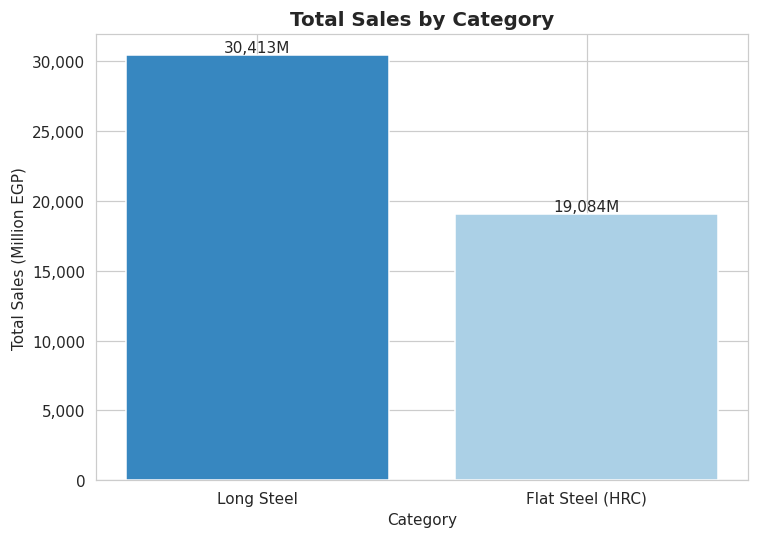

In [23]:
fig, ax = plt.subplots(figsize=(7,5))
colors = sns.color_palette('Blues_r', len(cat_sales))
ax.bar(cat_sales.index, cat_sales.values / 1e6, color=colors)
ax.set_title('Total Sales by Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Sales (Million EGP)')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
for i, v in enumerate(cat_sales.values / 1e6):
    ax.text(i, v, f"{v:,.0f}M", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('charts/01_sales_by_category.png', dpi=150)
plt.show()


### Chart 2 — Sales Over Time (Monthly)

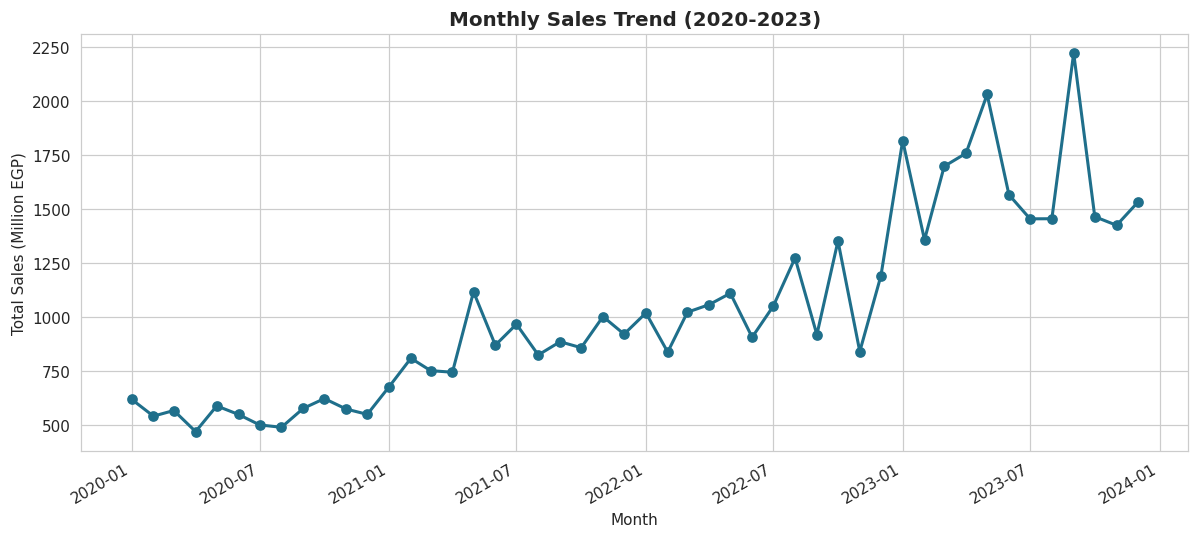

In [24]:
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(monthly['Period'], monthly['Sales'] / 1e6, marker='o', linewidth=2, color='#1f6f8b')
ax.set_title('Monthly Sales Trend (2020-2023)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales (Million EGP)')
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('charts/02_sales_over_time.png', dpi=150)
plt.show()


### Chart 3 — Top 10 Products by Sales

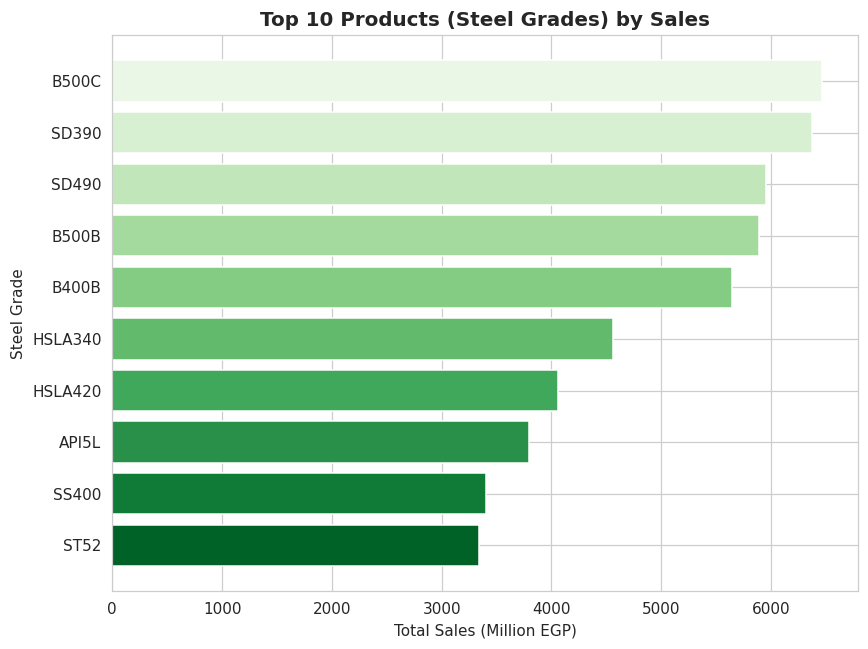

In [25]:
top10_plot = prod_by_sales.head(10).sort_values()
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(top10_plot.index, top10_plot.values / 1e6, color=sns.color_palette('Greens_r', 10))
ax.set_title('Top 10 Products (Steel Grades) by Sales', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Sales (Million EGP)')
ax.set_ylabel('Steel Grade')
plt.tight_layout()
plt.savefig('charts/03_top10_products.png', dpi=150)
plt.show()


### Chart 4 — Sales by Region

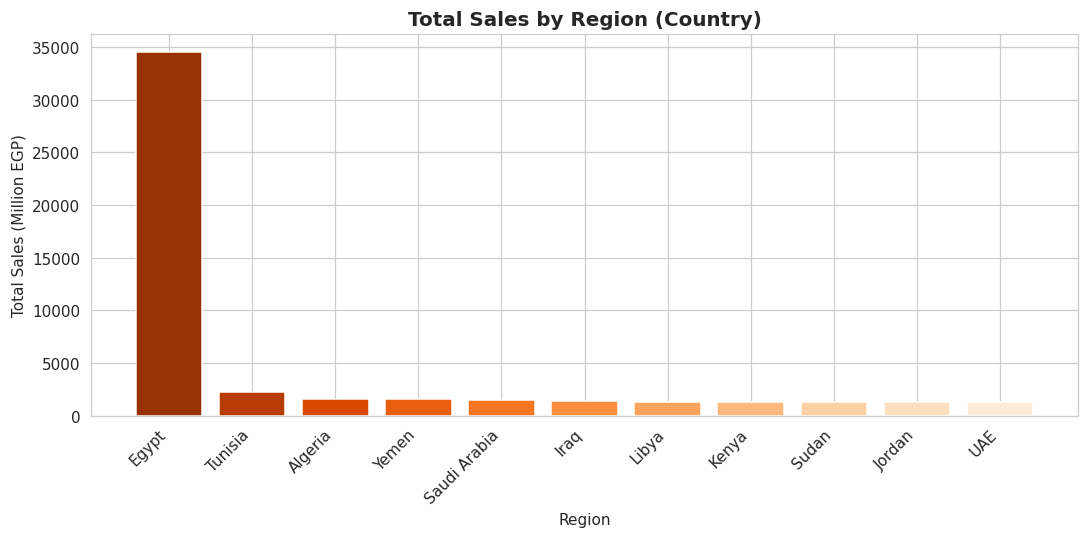

In [26]:
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(region_sales.index, region_sales.values / 1e6, color=sns.color_palette('Oranges_r', len(region_sales)))
ax.set_title('Total Sales by Region (Country)', fontsize=13, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales (Million EGP)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('charts/04_sales_by_region.png', dpi=150)
plt.show()


### Chart 5 (Optional) — Domestic vs Export Sales
Since roughly 30% of invoices in this dataset are exports, this extra chart shows how much revenue comes
from the domestic Egyptian market versus all export destinations combined.

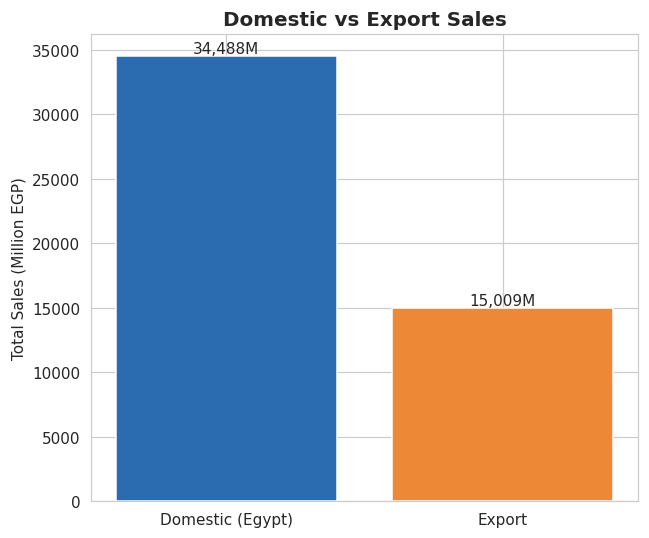

In [27]:
domestic_export = df.groupby(df['Region'].eq('Egypt').map({True:'Domestic (Egypt)', False:'Export'}))['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6,5))
ax.bar(domestic_export.index, domestic_export.values / 1e6, color=['#2b6cb0','#ed8936'])
ax.set_title('Domestic vs Export Sales', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Sales (Million EGP)')
for i, v in enumerate(domestic_export.values / 1e6):
    ax.text(i, v, f"{v:,.0f}M", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('charts/05_domestic_vs_export.png', dpi=150)
plt.show()


## 7. Key Insights

Based strictly on the calculations above:

1. **Long Steel drives most of the revenue.** It generated about 61% of total sales versus ~39% for
   Flat Steel (HRC) — the company's revenue is concentrated in the long-steel product line.
2. **Egypt (domestic market) is by far the largest revenue source**, generating over 34.4 billion EGP —
   roughly 15x the sales of the next-largest single market (Tunisia). Exports are spread thinly across
   10 countries rather than concentrated in one.
3. **Revenue is concentrated in a handful of steel grades.** The top 3 grades (B500C, SD390, B500B) each
   bring in roughly similar amounts and together account for a large share of total sales — no single
   grade dominates overwhelmingly, unlike the category-level split.
4. **Sales grew strongly and consistently year over year.** Annual revenue nearly tripled from about
   6.8 billion EGP in 2020 to about 19.9 billion EGP in 2023 (roughly +195%), with every year higher than
   the last — the month-to-month line still zig-zags (individual months swing up and down), but the
   underlying yearly trend is clearly upward rather than flat or seasonal.
5. **Sales volume (revenue) cannot be assumed to equal profitability.** Because no per-invoice cost data
   exists in this dataset, a category or region that leads in sales (e.g. Long Steel, Egypt) cannot be
   assumed to also be the most profitable — that would require cost data this dataset does not provide.


## 8. Final Summary

In [28]:
print("="*60)
print("FINAL PROJECT SUMMARY")
print("="*60)
print(f"Total Sales:              {total_sales:,.0f} EGP")
print(f"Total Quantity Sold:      {total_qty:,.0f} tons")
print(f"Best Performing Category: {cat_sales.index[0]} ({cat_sales.iloc[0]:,.0f} EGP)")
print(f"Best-Selling Product:     {prod_by_sales.index[0]} ({prod_by_sales.iloc[0]:,.0f} EGP, by revenue)")
print(f"Top Region:               {region_sales.index[0]} ({region_sales.iloc[0]:,.0f} EGP)")
print(f"Best Sales Month:         {highest_month['Period'].strftime('%B %Y')} ({highest_month['Sales']:,.0f} EGP)")
print(f"Worst Sales Month:        {lowest_month['Period'].strftime('%B %Y')} ({lowest_month['Sales']:,.0f} EGP)")
print("="*60)
print("Note: Profit could not be calculated at product/category/region level -")
print("Sales_Transactions has no cost data. Company-wide net profit (context only,")
print(f"from Monthly_Financial) was {company_total_profit_m:,.0f} million EGP over the same period.")


FINAL PROJECT SUMMARY
Total Sales:              49,497,054,174 EGP
Total Quantity Sold:      3,016,635 tons
Best Performing Category: Long Steel (30,413,173,143 EGP)
Best-Selling Product:     B500C (6,469,163,344 EGP, by revenue)
Top Region:               Egypt (34,487,714,126 EGP)
Best Sales Month:         September 2023 (2,223,174,097 EGP)
Worst Sales Month:        April 2020 (471,086,337 EGP)
Note: Profit could not be calculated at product/category/region level -
Sales_Transactions has no cost data. Company-wide net profit (context only,
from Monthly_Financial) was 18,183 million EGP over the same period.


**Key Insights (recap):**
1. Long Steel is the dominant revenue-generating category (~61% of sales).
2. Egypt is the dominant market, far outselling any single export destination.
3. Revenue is fairly spread across the top steel grades rather than one grade dominating.
4. Annual revenue nearly tripled from 2020 to 2023 (+195%), a clear multi-year growth trend.
5. High sales (revenue) cannot be equated with high profit without cost data, which this dataset lacks
   at the transaction level.

---
*This project uses only the provided EzzSteel dataset. No values were invented; every number above is
calculated directly from `Sales_Transactions` after the cleaning steps documented in Section 3 (with one
clearly-labeled exception: the company-wide Net Profit figure, sourced from `Monthly_Financial` for
context only).*
